📊 Cargando datos del CSV...
✅ Se cargaron 490 videos exitosamente.



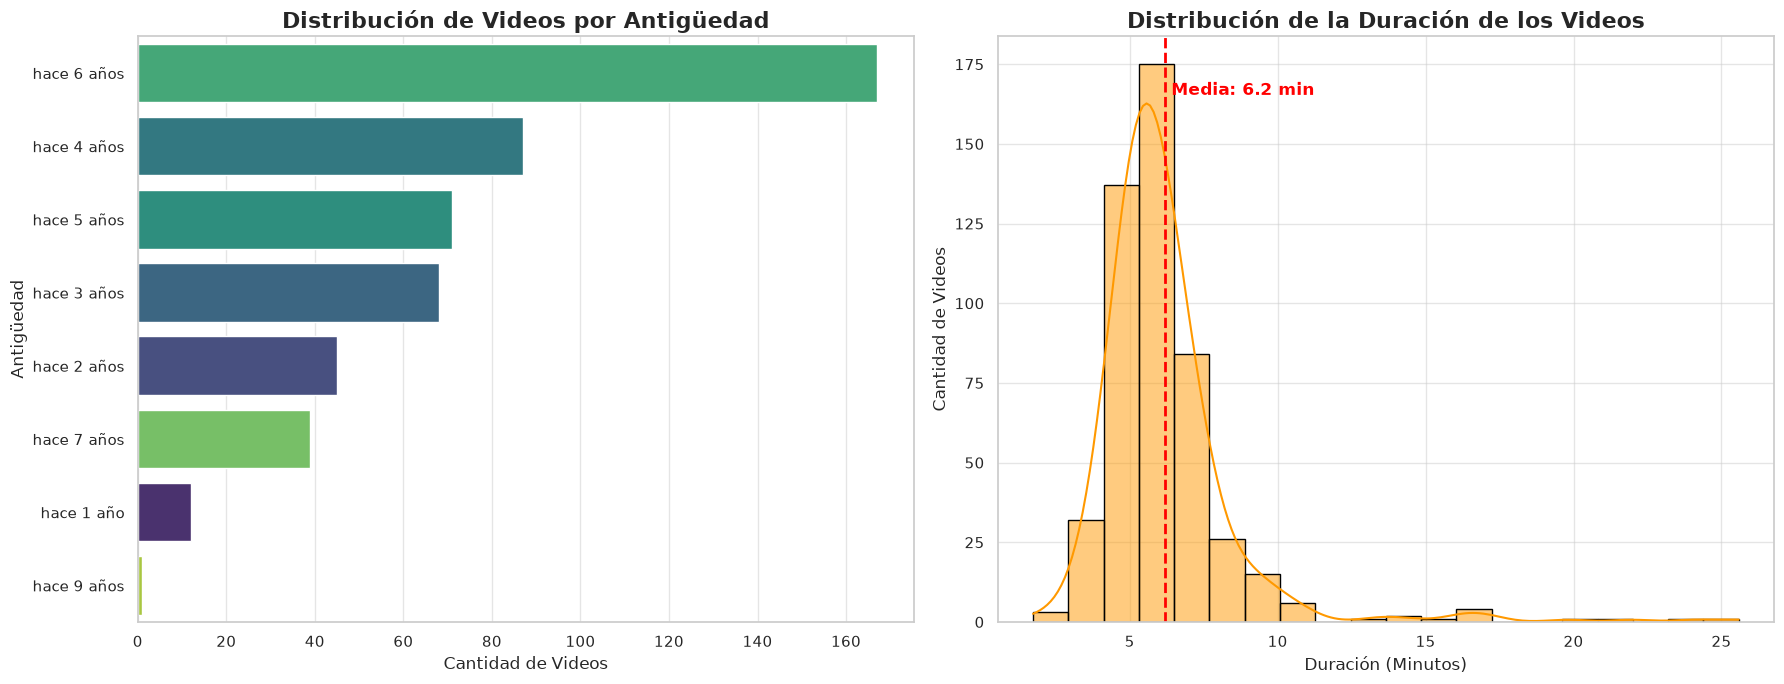

📈 RESUMEN ESTADÍSTICO DE LA DURACIÓN:
count    490.00
mean       6.21
std        2.42
min        1.73
25%        5.00
50%        5.76
75%        6.75
max       25.58
Name: duration_mins, dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. CONFIGURACIÓN Y LECTURA
# ---------------------------------------------------------
# Ruta exacta basada en tu captura del árbol de archivos
CSV_PATH = Path('/home/stemjara/Projects/AWS-Architecture/videos.csv')

# Usamos el tema estético de seaborn
sns.set_theme(style="whitegrid")

print("📊 Cargando datos del CSV...")
df = pd.read_csv(CSV_PATH)
print(f"✅ Se cargaron {len(df)} videos exitosamente.\n")

# 2. LIMPIEZA DE DATOS
# ---------------------------------------------------------
def convertir_a_minutos(tiempo_str):
    """Convierte el formato 'M:SS' o 'H:MM:SS' a minutos decimales."""
    try:
        partes = str(tiempo_str).strip().split(':')
        if len(partes) == 2:
            return int(partes[0]) + int(partes[1]) / 60.0
        elif len(partes) == 3:
            return int(partes[0]) * 60 + int(partes[1]) + int(partes[2]) / 60.0
    except Exception:
        return None
    return None

# Aplicar la limpieza a la columna duration
df['duration_mins'] = df['duration'].apply(convertir_a_minutos)

# Limpiar espacios extra en la columna age por si acaso
df['age'] = df['age'].astype(str).str.strip()


# 3. VISUALIZACIÓN (DASHBOARD)
# ---------------------------------------------------------
# Crear una figura con 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfico 1: Distribución por Edad (Fechas) ---
# Ordenamos las categorías por cantidad de videos de mayor a menor
orden_edades = df['age'].value_counts().index

sns.countplot(
    data=df,
    y='age',
    order=orden_edades,
    ax=axes[0],
    palette="viridis",
    hue='age', # Se añade hue para evitar warnings de seaborn
    legend=False
)
axes[0].set_title('Distribución de Videos por Antigüedad', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Cantidad de Videos', fontsize=12)
axes[0].set_ylabel('Antigüedad', fontsize=12)

# --- Gráfico 2: Distribución de la Duración ---
# Usamos un histograma con una curva de densidad (KDE)
sns.histplot(
    data=df,
    x='duration_mins',
    bins=20,
    kde=True,
    ax=axes[1],
    color="#FF9900", # Color naranja estilo AWS
    edgecolor="black"
)
axes[1].set_title('Distribución de la Duración de los Videos', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Duración (Minutos)', fontsize=12)
axes[1].set_ylabel('Cantidad de Videos', fontsize=12)

# Añadir una línea vertical mostrando la duración promedio
duracion_promedio = df['duration_mins'].mean()
axes[1].axvline(duracion_promedio, color='red', linestyle='dashed', linewidth=2)
axes[1].text(duracion_promedio + 0.2, axes[1].get_ylim()[1]*0.9, f'Media: {duracion_promedio:.1f} min', color='red', fontweight='bold')

# Ajustar márgenes y mostrar
plt.tight_layout()
plt.show()

# Extra: Imprimir un pequeño resumen estadístico
print("📈 RESUMEN ESTADÍSTICO DE LA DURACIÓN:")
print(df['duration_mins'].describe().round(2))

In [2]:
ruta_reporte = '/home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/evaluation_per_video.csv'
rute_compare = '/home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/three_graphs_comparison.csv'

📊 Cargando métricas de grafos...
✅ Se cargaron 125 reportes de video.



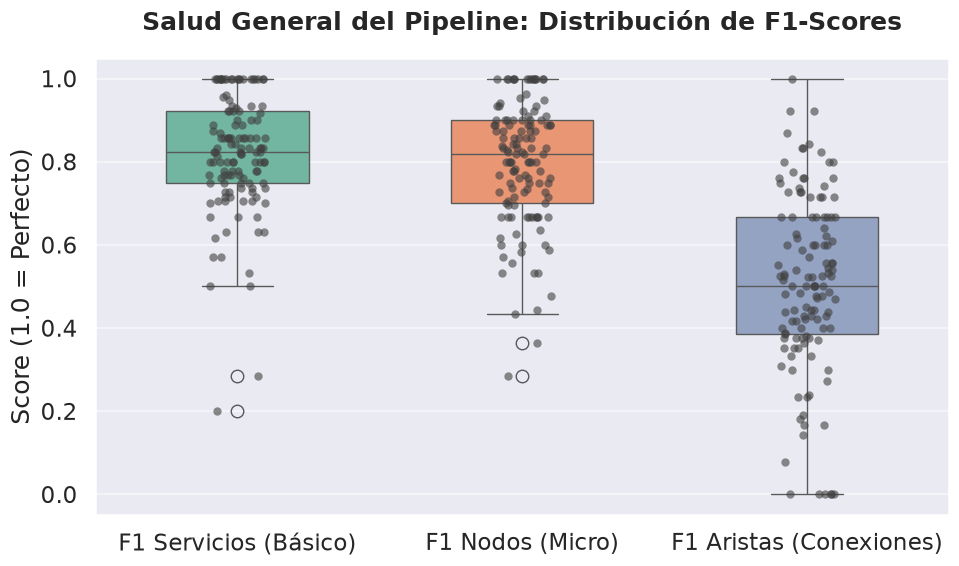

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# 1. CONFIGURACIÓN Y LECTURA
# ==========================================
CSV_PATH = Path(ruta_reporte)

# Estilo visual
sns.set_theme(style="darkgrid", context="talk")

print("📊 Cargando métricas de grafos...")
df = pd.read_csv(CSV_PATH)
print(f"✅ Se cargaron {len(df)} reportes de video.\n")

def graficar_salud_general(df):
    plt.figure(figsize=(10, 6))

    # Seleccionamos las métricas F1 clave
    metricas = ['svc_f1', 'ms_f1', 'edge_f1']
    nombres_legibles = ['F1 Servicios (Básico)', 'F1 Nodos (Micro)', 'F1 Aristas (Conexiones)']

    # Preparamos los datos para seaborn
    df_melted = df.melt(value_vars=metricas, var_name='Metrica', value_name='F1 Score')

    # Gráfico de cajas (CORREGIDO: hue='Metrica' y legend=False para evitar FutureWarning)
    ax = sns.boxplot(x='Metrica', y='F1 Score', hue='Metrica', data=df_melted, palette="Set2", width=0.5, legend=False)
    sns.stripplot(x='Metrica', y='F1 Score', data=df_melted, color=".25", size=6, alpha=0.6)

    # Etiquetas (CORREGIDO: set_xticks fijado antes de set_xticklabels para evitar UserWarning)
    ax.set_xticks(range(len(nombres_legibles)))
    ax.set_xticklabels(nombres_legibles)

    plt.title('Salud General del Pipeline: Distribución de F1-Scores', fontweight='bold', pad=20)
    plt.ylim(-0.05, 1.05) # El F1 va de 0 a 1
    plt.ylabel('Score (1.0 = Perfecto)')
    plt.xlabel('')

    plt.tight_layout()
    plt.show()

graficar_salud_general(df)


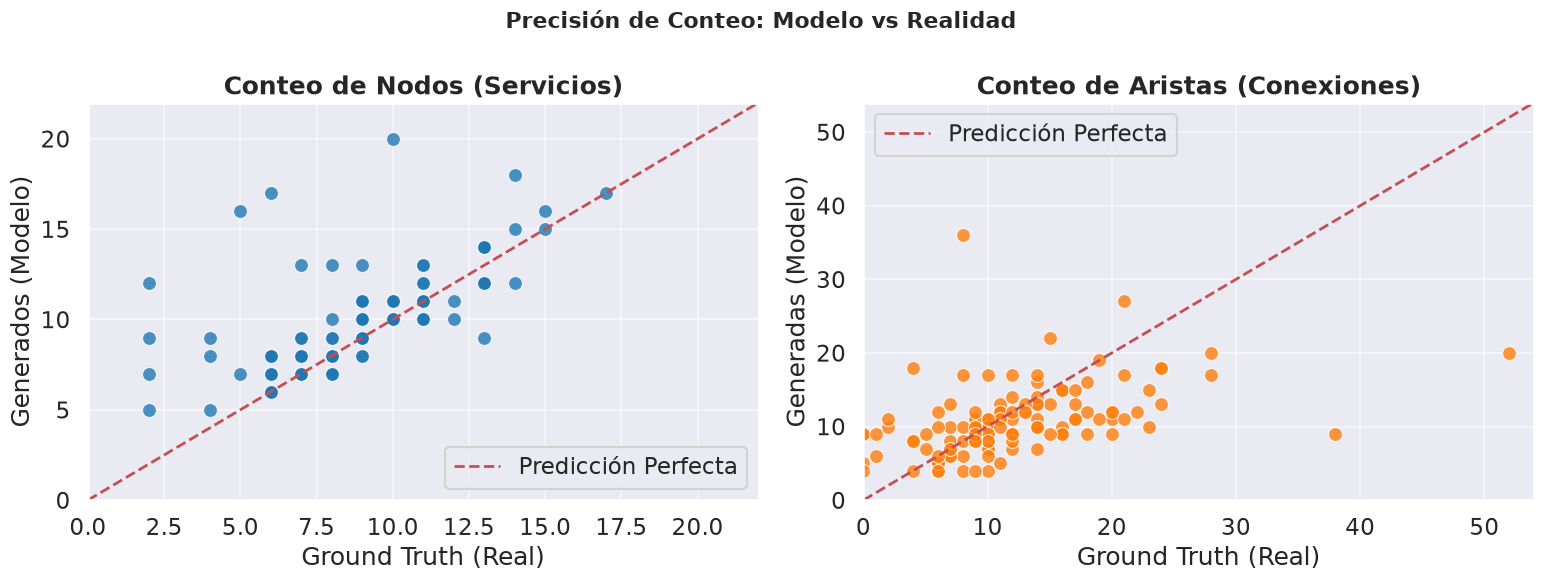

In [4]:
def graficar_prediccion_vs_realidad(df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Límite máximo para que los ejes sean simétricos
    max_nodes = max(df['gen_nodes'].max(), df['gt_nodes'].max()) + 2
    max_edges = max(df['gen_edges'].max(), df['gt_edges'].max()) + 2

    # --- Gráfico 1: Nodos ---
    sns.scatterplot(x='gt_nodes', y='gen_nodes', data=df, ax=axes[0], s=100, color="#1f77b4", alpha=0.8)
    axes[0].plot([0, max_nodes], [0, max_nodes], 'r--', lw=2, label='Predicción Perfecta')
    axes[0].set_title('Conteo de Nodos (Servicios)', fontweight='bold')
    axes[0].set_xlabel('Ground Truth (Real)')
    axes[0].set_ylabel('Generados (Modelo)')
    axes[0].set_xlim(0, max_nodes)
    axes[0].set_ylim(0, max_nodes)
    axes[0].legend()

    # --- Gráfico 2: Aristas ---
    sns.scatterplot(x='gt_edges', y='gen_edges', data=df, ax=axes[1], s=100, color="#ff7f0e", alpha=0.8)
    axes[1].plot([0, max_edges], [0, max_edges], 'r--', lw=2, label='Predicción Perfecta')
    axes[1].set_title('Conteo de Aristas (Conexiones)', fontweight='bold')
    axes[1].set_xlabel('Ground Truth (Real)')
    axes[1].set_ylabel('Generadas (Modelo)')
    axes[1].set_xlim(0, max_edges)
    axes[1].set_ylim(0, max_edges)
    axes[1].legend()

    plt.suptitle('Precisión de Conteo: Modelo vs Realidad', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

graficar_prediccion_vs_realidad(df)

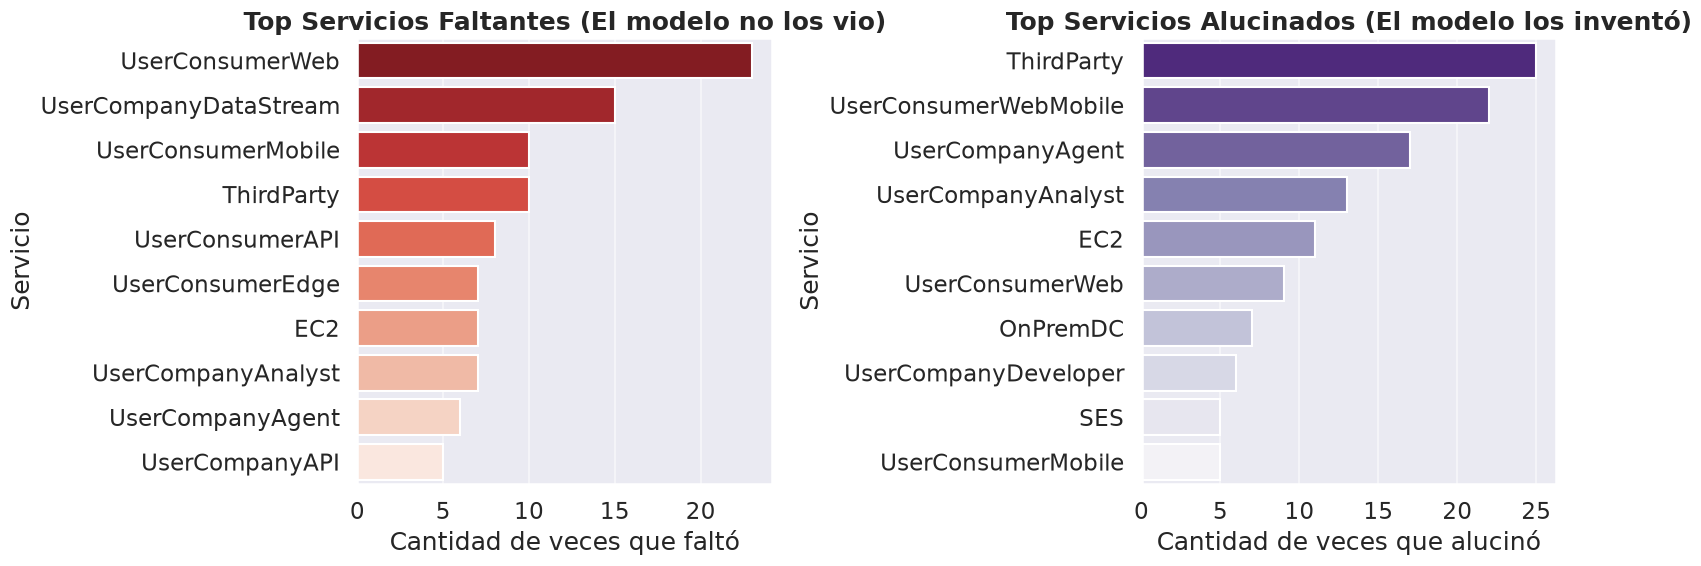

In [5]:
def auditar_alucinaciones_y_faltantes(df):
    from collections import Counter
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Extraer y contar servicios faltantes
    faltantes = df['services_missing'].dropna().astype(str)
    lista_faltantes = [serv.strip() for fila in faltantes for serv in fila.split(',')]
    conteo_faltantes = Counter(lista_faltantes)

    # Extraer y contar servicios alucinados
    alucinados = df['services_hallucinated'].dropna().astype(str)
    lista_alucinados = [serv.strip() for fila in alucinados for serv in fila.split(',')]
    conteo_alucinados = Counter(lista_alucinados)

    # Crear DataFrames para graficar
    df_faltantes = pd.DataFrame(conteo_faltantes.items(), columns=['Servicio', 'Frecuencia']).sort_values(by='Frecuencia', ascending=False).head(10)
    df_alucinados = pd.DataFrame(conteo_alucinados.items(), columns=['Servicio', 'Frecuencia']).sort_values(by='Frecuencia', ascending=False).head(10)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico de Faltantes (Falsos Negativos) - CORREGIDO: hue y legend=False
    if not df_faltantes.empty:
        sns.barplot(x='Frecuencia', y='Servicio', hue='Servicio', data=df_faltantes, ax=axes[0], palette="Reds_r", legend=False)
        axes[0].set_title('Top Servicios Faltantes (El modelo no los vio)', fontweight='bold')
        axes[0].set_xlabel('Cantidad de veces que faltó')
    else:
        axes[0].text(0.5, 0.5, 'Sin servicios faltantes 🎉', ha='center', va='center', fontsize=14)

    # Gráfico de Alucinados (Falsos Positivos) - CORREGIDO: hue y legend=False
    if not df_alucinados.empty:
        sns.barplot(x='Frecuencia', y='Servicio', hue='Servicio', data=df_alucinados, ax=axes[1], palette="Purples_r", legend=False)
        axes[1].set_title('Top Servicios Alucinados (El modelo los inventó)', fontweight='bold')
        axes[1].set_xlabel('Cantidad de veces que alucinó')
    else:
        axes[1].text(0.5, 0.5, 'Sin alucinaciones 🎉', ha='center', va='center', fontsize=14)

    plt.tight_layout()
    plt.show()

auditar_alucinaciones_y_faltantes(df)

In [6]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

def extraer_datos_iconos(frames_dir):
    """
    Recorre una carpeta de frames, detecta los cuadros (íconos) y guarda
    su información (centro cartesiano, tamaño, área) en un DataFrame de Pandas.
    """
    frames_path = Path(frames_dir)
    datos_cuadros = []
    min_area = 10000
    print(f"📂 Analizando frames en: {frames_dir}...")

    # Usamos un kernel de 13x13 como corregimos anteriormente
    kernel_corte = np.ones((13, 13), np.uint8)

    for fp in frames_path.glob("*.jpg"):
        img = cv2.imread(str(fp))
        if img is None: continue

        H, W = img.shape[:2]
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # Máscara de saturación para los íconos de AWS
        sat_mask_raw = (hsv[:, :, 1] > 80) & (hsv[:, :, 2] > 60)
        sat_mask = cv2.morphologyEx(sat_mask_raw.astype(np.uint8), cv2.MORPH_OPEN, kernel_corte)

        # Encontrar contornos
        contours, _ = cv2.findContours(sat_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            area = cv2.contourArea(cnt)

            # Filtro holgado de relación de aspecto para asegurarnos de que es un "cuadro"
            # Lo dejamos un poco más amplio (0.7 a 1.3) para recolectar buena data
            if 0.7 < (w / h) < 1.3 and area > min_area:

                # 1. Calcular el centro en coordenadas de OpenCV (Top-Left origin)
                cx_cv = x + (w / 2)
                cy_cv = y + (h / 2)

                # ====================================================================
                # 🛑 BLOQUE OPCIONAL: DELIMITAR LA ZONA DE LA PIZARRA (WHITEBOARD ROI)
                # ====================================================================
                # Si quieres eliminar los cuadrados detectados en los bordes de la
                # imagen (fuera de la pizarra), DESCOMENTA las siguientes 4 líneas.
                # Usa las proporciones que ya tenías en tus filtros anteriores:

                limite_x_min, limite_x_max = W * 0.28, W * 0.72
                limite_y_min, limite_y_max = H * 0.10, H * 0.90
                if not (limite_x_min <= cx_cv <= limite_x_max and limite_y_min <= cy_cv <= limite_y_max):
                     continue  # Ignoramos este cuadro porque está fuera de la zona útil
                # ====================================================================

                # 2. Transformar a coordenadas cartesianas (Bottom-Left origin)
                cx_cartesian = cx_cv
                cy_cartesian = H - cy_cv # Invertimos el eje Y

                # Guardar los datos en la lista
                datos_cuadros.append({
                    "frame": fp.name,
                    "cx": cx_cartesian,
                    "cy": cy_cartesian,
                    "ancho": w,
                    "alto": h,
                    "area": area
                })

    # Convertir la lista de diccionarios a un DataFrame de Pandas
    df = pd.DataFrame(datos_cuadros)
    print(f"✅ Extracción completada. Se encontraron {len(df)} cuadros en total.")
    return df


def analizar_y_graficar_cuadros(df):
    """
    Toma el DataFrame generado y crea gráficos estadísticos para determinar
    el área mínima y visualizar las posiciones más frecuentes.
    """
    if df.empty:
        print("El DataFrame está vacío. No hay nada que graficar.")
        return

    # Crear una figura con 2 subgráficos
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_theme(style="whitegrid")

    # ---------------------------------------------------------
    # Gráfico 1: Histograma de Áreas (Para definir min_area_icono)
    # ---------------------------------------------------------
    # Esto te mostrará picos. Los picos bajos suelen ser ruido/tiza,
    # los picos altos son los íconos reales de distintos tamaños.
    sns.histplot(data=df, x="area", bins=50, kde=True, ax=axes[0], color="blue")
    axes[0].set_title("Distribución de Áreas de los Cuadros Detectados", fontweight='bold')
    axes[0].set_xlabel("Área (Píxeles)")
    axes[0].set_ylabel("Frecuencia (Nº de veces detectado)")

    # ---------------------------------------------------------
    # Gráfico 2: Mapa de Dispersión (Scatter) de Posiciones
    # ---------------------------------------------------------
    # (0,0) estará en la esquina inferior izquierda.
    # El tamaño del punto (s) representará el área del ícono.
    scatter = sns.scatterplot(
        data=df,
        x="cx",
        y="cy",
        size="area",
        hue="area", # Color basado en el tamaño para diferenciar rápido
        palette="viridis",
        sizes=(20, 200),
        alpha=0.6,
        ax=axes[1]
    )
    axes[1].set_title("Posición Cartesiana de los Íconos (Origen: Inferior Izquierda)", fontweight='bold')
    axes[1].set_xlabel("Posición X")
    axes[1].set_ylabel("Posición Y")

    # Forzar que el origen del gráfico 2 empiece en 0,0 para mayor claridad
    axes[1].set_xlim(left=0)
    axes[1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

    # Mostrar un resumen estadístico útil en la consola
    print("\n📊 RESUMEN ESTADÍSTICO DE ÁREAS:")
    print(df['area'].describe())

In [7]:
# 1. Extraes la data a un DataFrame
ruta_frames = PROJECT_ROOT / 'whiteboard_selection_lab' / 'frames_new' / VIDEO_ID
df_iconos = extraer_datos_iconos(FRAMES_DIR)

# 2. Generas las visualizaciones para tomar decisiones
analizar_y_graficar_cuadros(df_iconos)

NameError: name 'PROJECT_ROOT' is not defined